# Code Stylometry and Authorship Verification
This notebook loads the Kaggle dataset, extracts stylometric features (Java-specific syntax and AST structures), and trains an XGBoost model. 

You can run these cells to interactively view the accuracy, classification reports, and generated graphs (Confusion Matrix, ROC Curve, Feature Importance) directly in the notebook!

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_dataset
from src.feature_extraction import extract_features
from src.model import StylometryModel

In [2]:
# 1. Load the Google Code Jam Dataset
dataset_path = 'dataset/kaggle_data/gpt_java_gcj/dataset'
df = load_dataset(dataset_path)
print(f"\nTotal loaded: {len(df)} files from {df['author'].nunique()} unique authors.")

Error reading file dataset/kaggle_data/gpt_java_gcj/dataset/hiworldwzj_000000000019fd27_00000000002249e8_000000000020bdf9.java: 'utf-8' codec can't decode bytes in position 2227-2228: invalid continuation byte


Error reading file dataset/kaggle_data/gpt_java_gcj/dataset/grekiki_000000000019ffb9_000000000033b962_000000000033871f.java: 'utf-8' codec can't decode byte 0xc4 in position 2496: invalid continuation byte


Error reading file dataset/kaggle_data/gpt_java_gcj/dataset/ponyong_000000000019fd27_000000000027ad0e_000000000020bdf9.java: 'utf-8' codec can't decode bytes in position 1370-1371: invalid continuation byte
Error reading file dataset/kaggle_data/gpt_java_gcj/dataset/quatremains_000000000019fd27_0000000000217b71_000000000020993c.java: 'utf-8' codec can't decode bytes in position 922-923: invalid continuation byte


Error reading file dataset/kaggle_data/gpt_java_gcj/dataset/grekiki_000000000019ffb9_000000000033f481_00000000003386d0.java: 'utf-8' codec can't decode byte 0xc4 in position 2483: invalid continuation byte
Error reading file dataset/kaggle_data/gpt_java_gcj/dataset/eggbread_000000000019fd27_000000000029fe34_000000000020bdf9.java: 'utf-8' codec can't decode bytes in position 2025-2026: invalid continuation byte
Error reading file dataset/kaggle_data/gpt_java_gcj/dataset/Elvar_000000000019fd27_00000000002143f5_000000000020bdf9.java: 'utf-8' codec can't decode byte 0xc3 in position 796: invalid continuation byte
Error reading file dataset/kaggle_data/gpt_java_gcj/dataset/zzzzzq_000000000019fd27_00000000002622ab_000000000020993c.java: 'utf-8' codec can't decode bytes in position 665-666: invalid continuation byte


Error reading file dataset/kaggle_data/gpt_java_gcj/dataset/albus.star_000000000019fd74_00000000002b85fd_00000000002b3034.java: 'utf-8' codec can't decode bytes in position 669-670: invalid continuation byte
Error reading file dataset/kaggle_data/gpt_java_gcj/dataset/ponyong_000000000019fd74_00000000002bc1d3_00000000002b1353.java: 'utf-8' codec can't decode bytes in position 1541-1542: invalid continuation byte


...

Error reading file dataset/kaggle_data/gpt_java_gcj/dataset/quatremains_000000000019fd27_00000000002a5bb0_000000000020bdf9.java: 'utf-8' codec can't decode bytes in position 1956-1957: invalid continuation byte
Error reading file dataset/kaggle_data/gpt_java_gcj/dataset/thaim24_000000000019fef4_0000000000322564_00000000003179a1.java: 'utf-8' codec can't decode bytes in position 822-823: invalid continuation byte


Error reading file dataset/kaggle_data/gpt_java_gcj/dataset/APjojeongjin_000000000019fd27_000000000028890d_000000000020993c.java: 'utf-8' codec can't decode bytes in position 528-529: invalid continuation byte
Error reading file dataset/kaggle_data/gpt_java_gcj/dataset/FaithKang_000000000019fd27_000000000027ac2f_000000000020bdf9.java: 'utf-8' codec can't decode bytes in position 1978-1979: invalid continuation byte


Error reading file dataset/kaggle_data/gpt_java_gcj/dataset/axiom_000000000019fd27_000000000025d3d0_0000000000209a9f.java: 'utf-8' codec can't decode bytes in position 1792-1793: invalid continuation byte


Error reading file dataset/kaggle_data/gpt_java_gcj/dataset/albus.star_000000000019fef4_0000000000320195_00000000003179a1.java: 'utf-8' codec can't decode bytes in position 1073-1074: invalid continuation byte


Loaded 76024 files from 6680 authors.

Total loaded: 76024 files from 6680 unique authors.


In [3]:
# 2. Extract Stylometric Features
# This step parses syntax (brackets, semicolons, keywords) and structural data.
features_df = extract_features(df)
features_df.head()

,code,author,loc,avg_line_length,num_comments,blank_lines,tabs_count,spaces_count,semicolons,braces,...,kw_if,kw_return,brace_new_line,ast_max_depth,ast_num_functions,ast_num_classes,ast_num_loops,ast_num_if,ast_num_returns,ast_num_imports
0,import java.util.*;\nimport java.io.*;\npublic...,sf14t,51,27.921569,2,4,0,470,33,8,...,4,0,0,0,0,0,0,0,0,0
1,import java.util.*;\nimport java.io.*;\n\n\npu...,omkar710,137,18.985401,4,34,0,918,77,25,...,5,4,2,0,0,0,0,0,0,0
2,\nimport java.util.HashSet;\nimport java.util....,KirtanShah,61,21.131148,3,5,74,480,36,12,...,0,0,12,0,0,0,0,0,0,0
3,import java.util.*;\nimport java.io.*;\n\n\npu...,natethegreat,58,21.413793,2,6,107,210,36,12,...,3,0,0,0,0,0,0,0,0,0
4,\n/**\n *\n * @author Tanmay Deshpande (KIT Co...,tanmay15,168,24.154762,7,34,1,2191,69,31,...,7,5,17,0,0,0,0,0,0,0


In [4]:
# 3. Train the XGBoost Classifier
# The model limits training to the top 50 most prolific authors to speed up evaluation.
model = StylometryModel()
xgb_model, report, accuracy = model.train(features_df, save_plots=True)
print(f"\n🏆 Final Model Accuracy: {accuracy * 100:.2f}%")

Dataset has 6680 authors. Keeping top 50 most prolific authors for faster training...
Training XGBoost model...


Evaluating model...
Accuracy: 0.8695



🏆 Final Model Accuracy: 86.95%


/var/folders/yk/5k0gbl895dj22rs7x77dl6dr0000gn/T/ipykernel_35163/3705741820.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(15), palette='viridis')


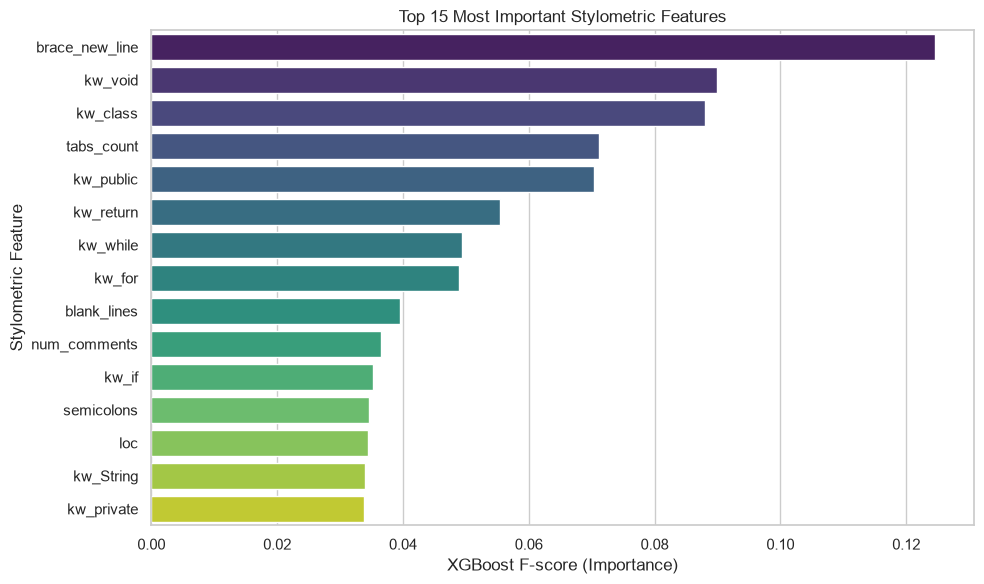

In [5]:
# 4. Visualize Feature Importance
# See which stylometric traits XGBoost relied on most to fingerprint the authors.
importance_scores = xgb_model.feature_importances_
X = features_df.drop(['code', 'author'], axis=1)
feat_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importance_scores}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(15), palette='viridis')
plt.title('Top 15 Most Important Stylometric Features')
plt.xlabel('XGBoost F-score (Importance)')
plt.ylabel('Stylometric Feature')
plt.tight_layout()
plt.show()

--- Confusion Matrix ---


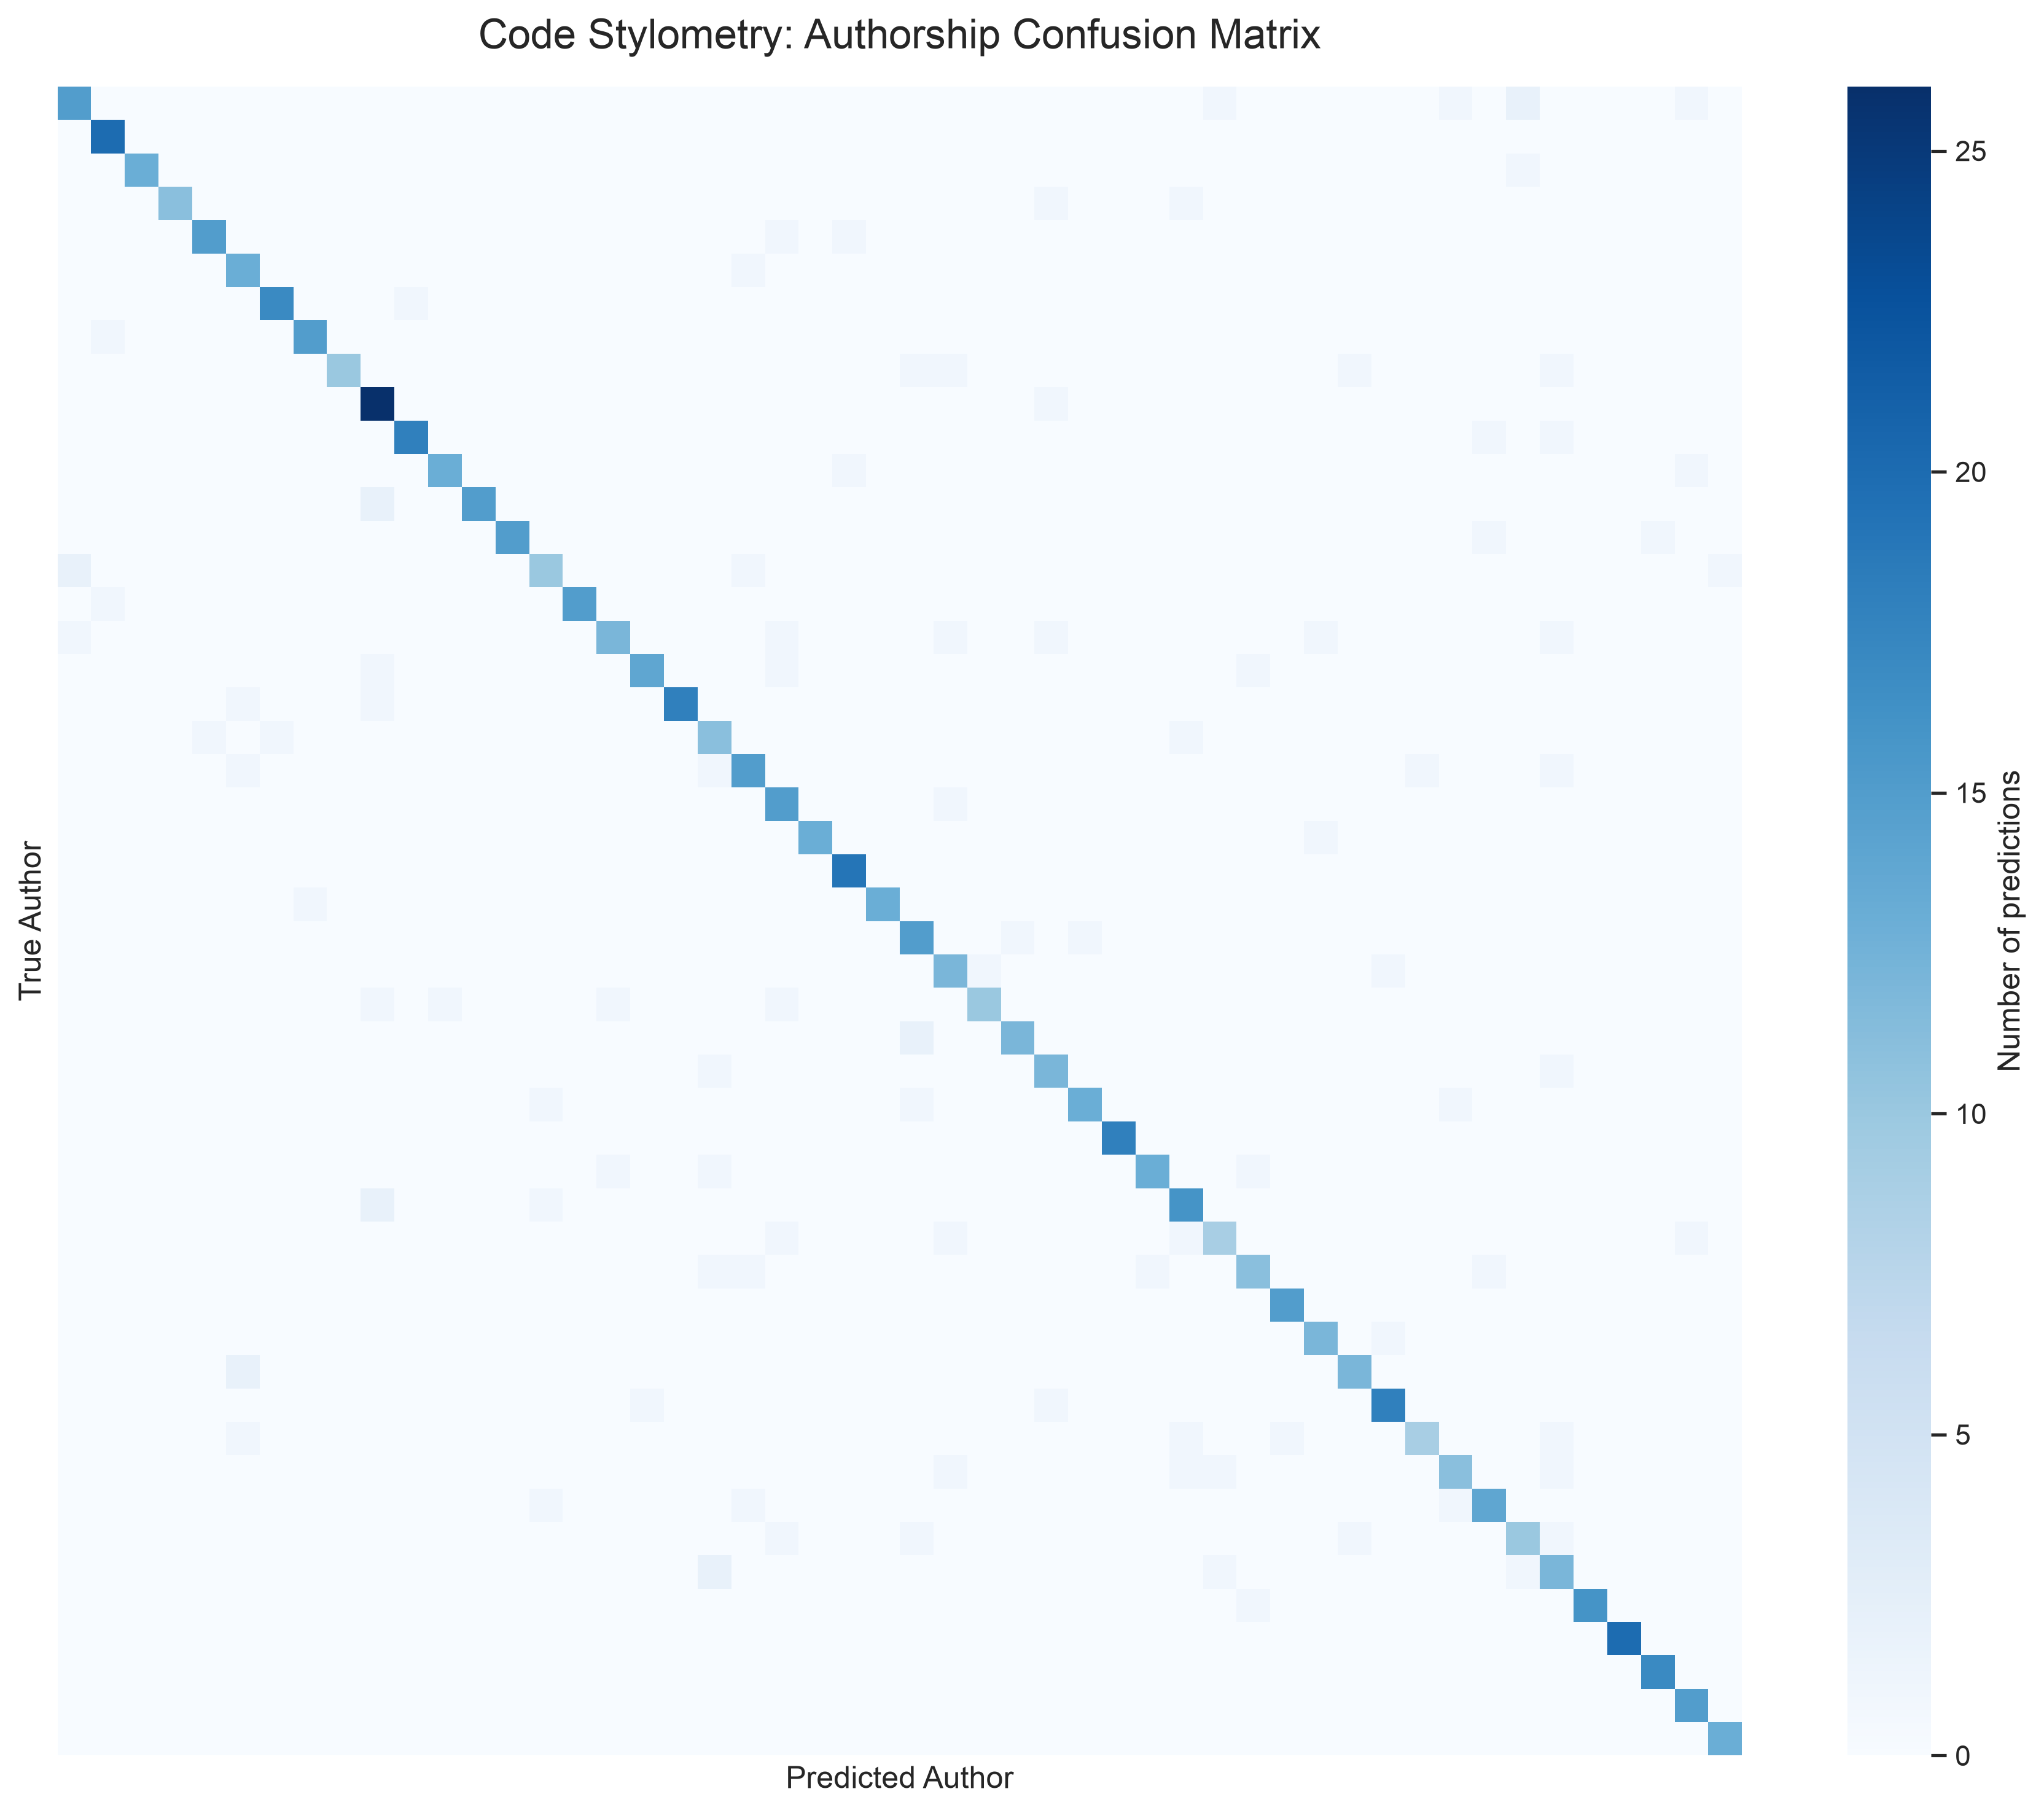

--- ROC Curve ---


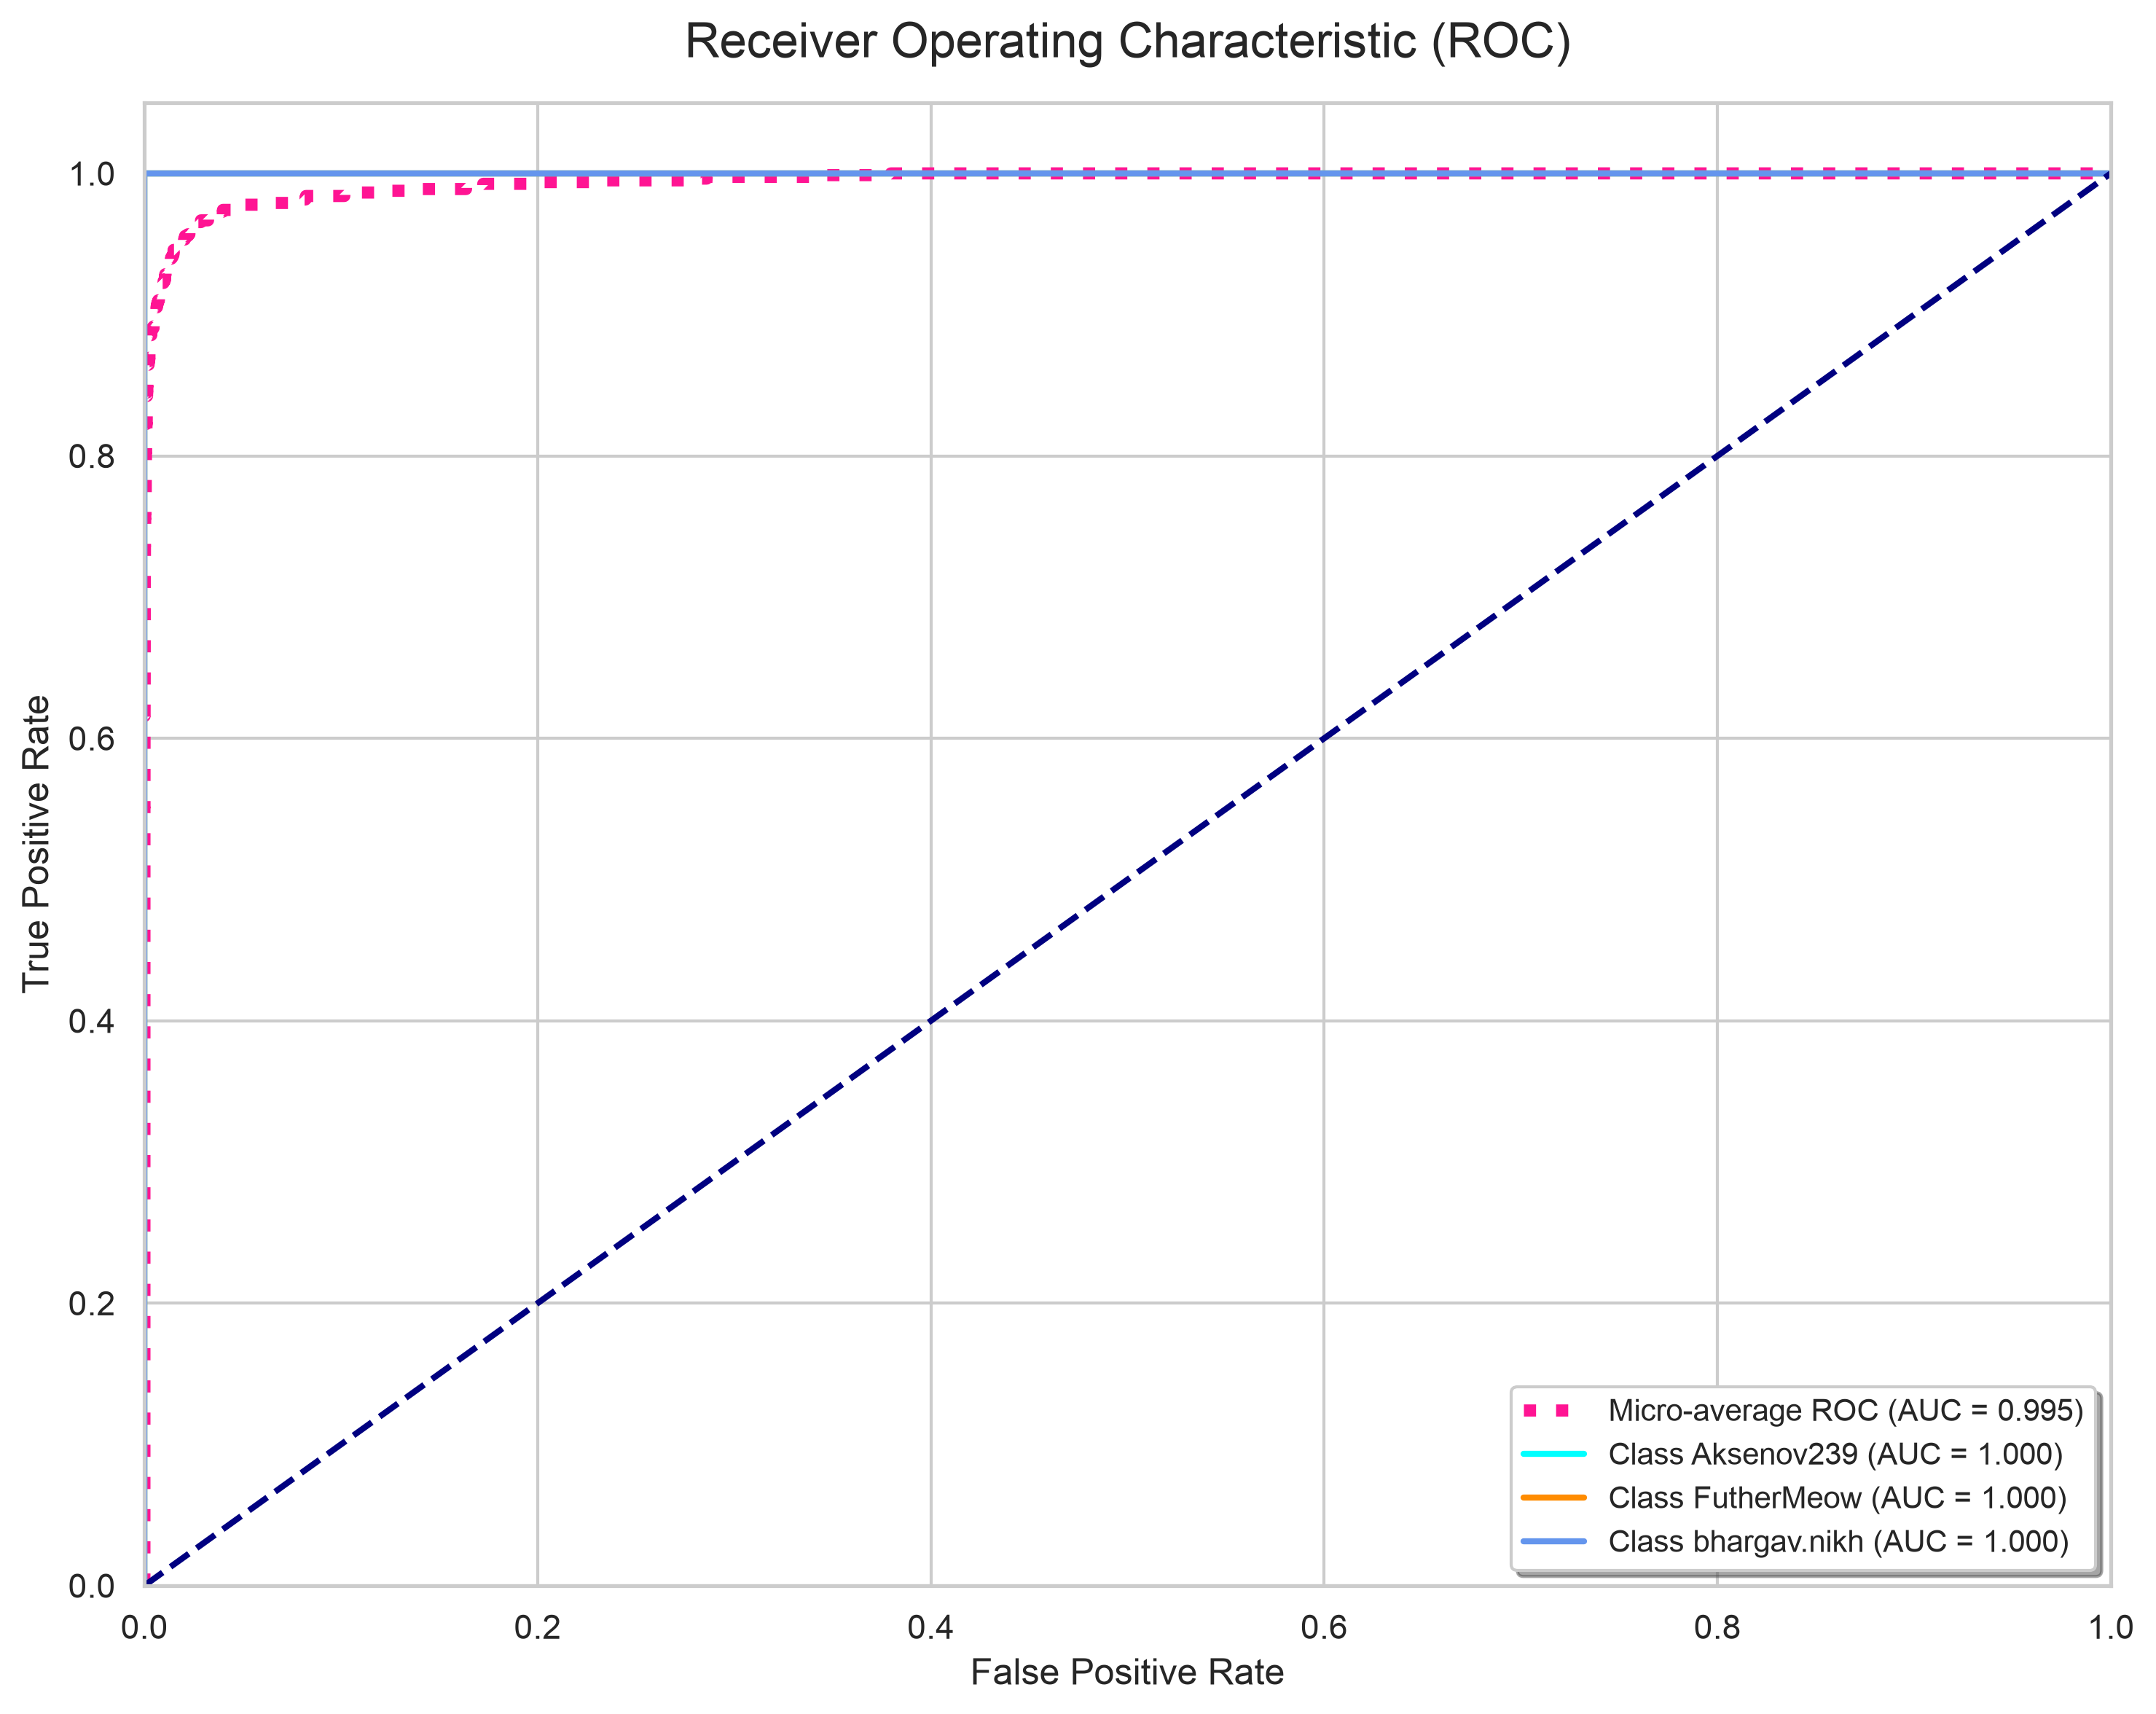

--- Precision-Recall Curve ---


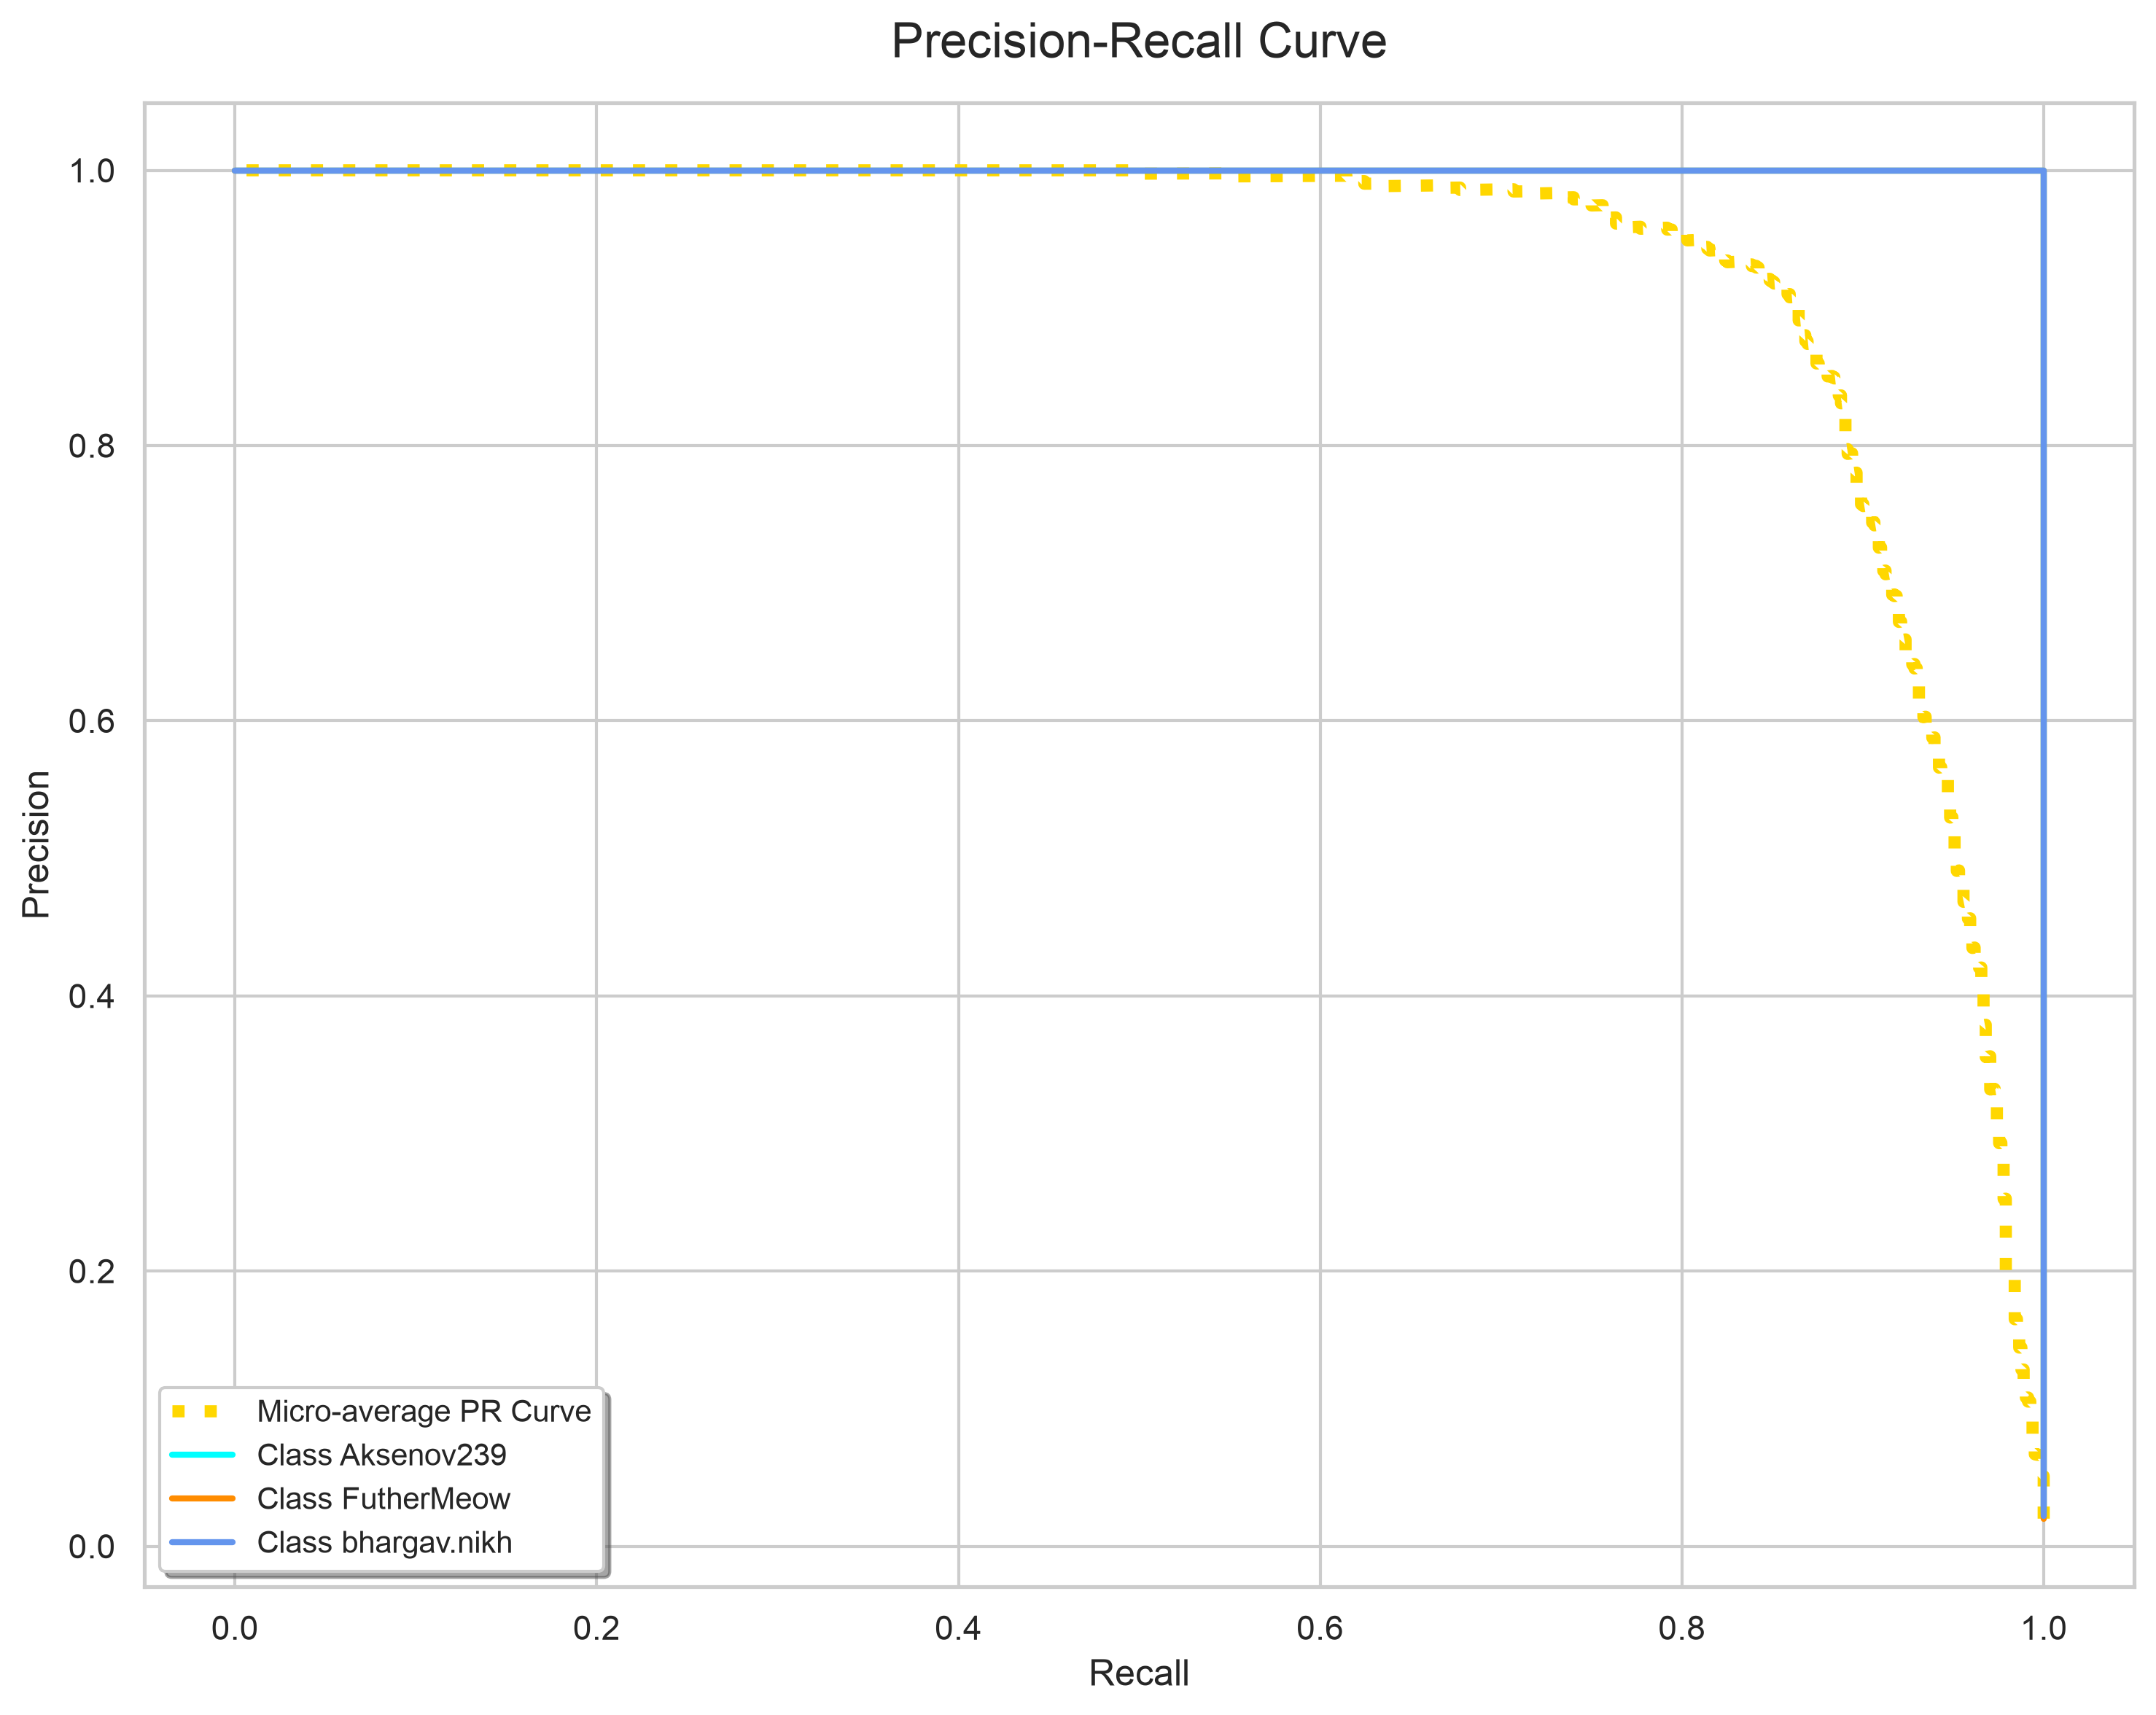

In [6]:
# 5. Display Evaluation Metrics & Graphs
# The training script automatically saved these graphs to the /results folder.
from IPython.display import Image, display

print("--- Confusion Matrix ---")
display(Image(filename='results/confusion_matrix.png'))

print("--- ROC Curve ---")
display(Image(filename='results/roc_curve.png'))

print("--- Precision-Recall Curve ---")
display(Image(filename='results/pr_curve.png'))